# Brent Oil Market Risk Analysis in R

Author: Zakariya Boutayeb

Instrument: Brent Crude Oil Futures (BZ=F) 

Analysis period: July 2007 through December 2023

Data Source: Yahoo Finance

This project studies the market risk of Brent crude oil using R. It retrieves daily Brent crude oil futures prices, calculates returns at several horizons, examines the return distribution, estimates Value at Risk (VaR) and Expected Shortfall (ES), and models changing volatility with a GARCH(1,1) model.

### Project highlights

- Retrieves daily `BZ=F` closing prices from Yahoo Finance.
- Requests data from 1 January 2006 through 8 September 2026.
- Calculates daily, monthly, quarterly, and yearly returns.
- Compares normal, empirical, and Student-t tail-risk estimates.
- Uses IID and consecutive-block simulations for a 10-day horizon.
- Diagnoses serial correlation and volatility clustering with ACF plots.
- Fits a GARCH(1,1) model with standardized Student-t innovations.
- Bootstraps one-day conditional VaR and ES.

### Research question

How much Brent oil downside risk is hidden by a constant-volatility normal model, and how do heavy tails, volatility clustering, and time dependence change the estimated risk?

### Data

- Asset: ICE Brent crude oil futures, Yahoo Finance symbol BZ=F.
- Requested sample: July 2007 to September 2026.
- Observed sample: 3,973 daily log returns after cleaning and the course-required removal of the first computed return.
- Software: R with quantmod, xts, MASS, and rugarch.


In [37]:
# Load packages
suppressPackageStartupMessages({
  library(quantmod)
  library(MASS)
  library(rugarch)
})

cat("Packages loaded successfully.\n")
cat("R version:", R.version.string, "\n")
cat("rugarch version:", as.character(packageVersion("rugarch")), "\n")

Packages loaded successfully.
R version: R version 4.4.3 (2025-02-28) 
rugarch version: 1.5.5 


In [38]:
# Download and clean Brent oil prices
brent <- suppressWarnings(getSymbols("BZ=F",src = "yahoo",
        from = "2006-01-01",to = "2026-09-09",auto.assign = FALSE)[, 4])

# Remove missing observations reported by Yahoo Finance
missing_before <- sum(is.na(brent))

brent <- na.omit(brent)
names(brent) <- "brent"

cat("Missing observations removed:", missing_before, "\n")
cat("Number of valid prices:", NROW(brent), "\n")
cat("First available price date:",as.character(first(index(brent))), "\n")
cat("Last available price date:",as.character(last(index(brent))), "\n")

Missing observations removed: 58 
Number of valid prices: 4756 
First available price date: 2007-07-30 
Last available price date: 2026-09-09 


In [8]:
# Calculate daily log returns
logret <- diff(log(brent))[-1]
logret <- na.omit(logret)

names(logret) <- "logret"
rvec <- as.numeric(logret)

head(logret)
tail(logret)

cat("Number of daily log returns:", NROW(logret), "\n")
cat("Return sample:", as.character(first(index(logret))),
    "to", as.character(last(index(logret))), "\n")
cat("Daily log return:","Date =", as.character(index(logret)[1]),
  "| Value =", sprintf("%.6f", as.numeric(logret[1])),"\n")

                 logret
2007-07-31  0.017148207
2007-08-01 -0.022310697
2007-08-02  0.005426572
2007-08-03 -0.013421265
2007-08-06 -0.049077857
2007-08-07  0.008813163

                 logret
2026-08-31  0.013125887
2026-09-01  0.044946570
2026-09-02  0.010300656
2026-09-03 -0.001150935
2026-09-04  0.007924986
2026-09-09  0.031086357

Number of daily log returns: 4755 
Return sample: 2007-07-31 to 2026-09-09 
Daily log return: Date = 2007-07-31 | Value = 0.017148 


In [9]:
# Calculate calendar-period returns
monthly_log <- apply.monthly(logret, sum)
monthly_discrete <- exp(monthly_log) - 1

quarterly_log <- apply.quarterly(logret, sum)
quarterly_discrete <- exp(quarterly_log) - 1

yearly_log <- apply.yearly(logret, sum)
yearly_discrete <- exp(yearly_log) - 1

cat("Monthly discrete return: Date =",as.character(index(monthly_discrete)[1]),
    "| Value =",sprintf("%.6f", as.numeric(monthly_discrete[1])),"\n")

cat("Quarterly log return: Date =",as.character(index(quarterly_log)[NROW(quarterly_log)]),
  "| Value =",sprintf("%.6f",as.numeric(quarterly_log[NROW(quarterly_log)])),"\n")

cat("Yearly discrete return: Date =", as.character(index(yearly_discrete)[NROW(yearly_discrete)]),
  "| Value =",sprintf("%.6f", as.numeric(yearly_discrete[NROW(yearly_discrete)])),"\n")

Monthly discrete return: Date = 2007-07-31 | Value = 0.017296 
Quarterly log return: Date = 2026-09-09 | Value = 0.308984 
Yearly discrete return: Date = 2026-09-09 | Value = 0.632210 


In [10]:
alpha99 <- 0.01

# Estimate Mean and standard deviation
mu <- mean(rvec)
sigma <- sd(rvec)

# Normal-distribution VaR and ES
normal_var <- qnorm(alpha99, mu, sigma)
normal_es <- mu - sigma * dnorm(qnorm(alpha99)) / alpha99

# Simulate from the normal distribution
set.seed(123789)
normal_sim <- rnorm(100000, mu, sigma)
normal_sim_var <- as.numeric(quantile(normal_sim, alpha99))
normal_sim_es <- mean(normal_sim[normal_sim < normal_sim_var])

# Simulate from the empirical distribution
set.seed(123789)
empirical_sim <- sample(rvec, 100000, replace = TRUE)
empirical_var <- as.numeric(quantile(empirical_sim, alpha99))
empirical_es <- mean(empirical_sim[empirical_sim < empirical_var])

# Most conservative ES for a $1 billion Brent Oil Position
most_conservative_es <- min(normal_es, normal_sim_es, empirical_es)
portfolio_es_dollars <- round(1000000000 * most_conservative_es)

# Print every answer on one line
cat("Mean:", sprintf("%.6f", mu), "\n")
cat("Standard deviation:", sprintf("%.6f", sigma), "\n")
cat("Normal 99% VaR:", sprintf("%.6f", normal_var),"\n")
cat("Normal 99% ES:",sprintf("%.6f", normal_es),"\n")
cat("Simulated-normal 99% VaR:",sprintf("%.6f", normal_sim_var),"\n")
cat("Simulated-normal 99% ES:",sprintf("%.6f", normal_sim_es),"\n")
cat("Empirical 99% VaR:",sprintf("%.6f", empirical_var),"\n")
cat("Empirical 99% ES:",sprintf("%.6f", empirical_es),"\n")
cat("Portfolio ES in whole dollars:",format(portfolio_es_dollars,
                            scientific = FALSE,trim = TRUE),"\n")

Mean: 0.000057 
Standard deviation: 0.024347 
Normal 99% VaR: -0.056582 
Normal 99% ES: -0.064832 
Simulated-normal 99% VaR: -0.057229 
Simulated-normal 99% ES: -0.065657 
Empirical 99% VaR: -0.071938 
Empirical 99% ES: -0.102214 
Portfolio ES in whole dollars: -102214063 


The empirical ES is substantially more negative than the normal ES meaning that the normal model understates the observed downside tail. 

For a hypothetical 1 billion Brent position, the most conservative one-day ES among the normal and empirical methods is approximately **-102,214,063**.

In [16]:
# Calculate skewness, kurtosis and Jarque–Bera statistic
alpha99 <- 0.01
n_simulations <- 100000

# Skewness, kurtosis, and Jarque-Bera test
n <- length(rvec)
centered_returns <- rvec - mean(rvec)
m2 <- mean(centered_returns^2)
m3 <- mean(centered_returns^3)
m4 <- mean(centered_returns^4)
skewness <- m3  / m2^(3 / 2)
kurtosis <- m4 / m2^2
jb <- (n / 6) * (skewness^2 + (kurtosis - 3)^2 / 4)
jb_pvalue <- pchisq(jb, df = 2, lower.tail = FALSE)

cat("Skewness:", sprintf("%.6f", skewness), "\n")
cat("Kurtosis:", sprintf("%.6f", kurtosis), "\n")
cat("Jarque-Bera statistic:", sprintf("%.6f", jb), "\n")
cat("Jarque-Bera p-value:", format(jb_pvalue, scientific = TRUE), "\n")

Skewness: -0.780057 
Kurtosis: 14.689060 
Jarque-Bera statistic: 27552.864331 
Jarque-Bera p-value: 0e+00 


The negative skewness, high kurtosis, and Jarque-Bera statistic provide strong evidence against normality.


In [18]:
# Fit the scaled Student-t distribution
student_fit <- suppressWarnings(fitdistr(rvec,densfun = "t"))
t_m <- unname(student_fit$estimate["m"])
t_s <- unname(student_fit$estimate["s"])
t_df <- unname(student_fit$estimate["df"])

cat("Student-t mean parameter m:",sprintf("%.6f", t_m), "\n")
cat("Student-t scale parameter s:",sprintf("%.6f", t_s), "\n")
cat("Student-t degrees of freedom:",sprintf("%.6f", t_df), "\n")

4. Student-t mean parameter m: 0.000874 
5. Student-t scale parameter s: 0.015131 
6. Student-t degrees of freedom: 3.033188 


In [19]:
# Calculate one-day Student-t VaR and ES
suppressWarnings(RNGkind(sample.kind = "Rounding"))

set.seed(123789)

student_1day <- t_m + t_s * rt(n = 100000,df = t_df)
student_1day_var <- as.numeric(quantile(student_1day, probs = alpha99))
student_1day_es <- mean(student_1day[student_1day < student_1day_var])

cat("Student-t one-day 99% VaR:",sprintf("%.6f", student_1day_var), "\n")
cat("Student-t one-day 99% ES:",sprintf("%.6f", student_1day_es), "\n")

Student-t one-day 99% VaR: -0.067535 
Student-t one-day 99% ES: -0.101710 


In [20]:
# Method 1: Student-t simulation over 10 days
suppressWarnings(RNGkind(sample.kind = "Rounding"))
set.seed(123789)
student_10day <- numeric(100000)

for (day in 1:10) {
  student_10day <- student_10day + t_m + t_s * rt(n=100000, df=t_df)
}

student_10day_var <- as.numeric(quantile(student_10day, alpha99))
student_10day_es <- mean(student_10day[student_10day < student_10day_var])

# Method 2: 10-day empirical IID simulation
suppressWarnings(RNGkind(sample.kind = "Rounding"))
set.seed(123789)
empirical_10day <- numeric(100000)

for (day in 1:10) {
  empirical_10day <- empirical_10day + sample(rvec, 100000, replace = TRUE)
}

empirical_10day_var <- as.numeric(quantile(empirical_10day, alpha99))
empirical_10day_es <- mean(empirical_10day[empirical_10day < empirical_10day_var])

# Method 3: 10-day blocks of consecutive observations
suppressWarnings(RNGkind(sample.kind = "Rounding"))
set.seed(123789)
starting_positions <- sample(1:(length(rvec) - 9), 100000, replace = TRUE)
block_10d <- numeric(100000)
positions <- starting_positions

for (day in 1:10) {
  block_10d <- block_10d + rvec[positions]
  positions <- positions + 1
}

block_10d_var <- as.numeric(quantile(block_10d, probs=alpha99))
block_10d_es <- mean(block_10d[block_10d < block_10d_var])

cat("Method 1 Student-t 10-day 99% VaR:", sprintf("%.6f", student_10day_var), "\n")
cat("Method 1 Student-t 10-day 99% ES:", sprintf("%.6f", student_10day_es), "\n")
cat("Method 2 empirical IID 10-day 99% VaR:", sprintf("%.6f", empirical_10day_var), "\n")
cat("Method 2 empirical IID 10-day 99% ES:", sprintf("%.6f", empirical_10day_es), "\n")
cat("Method 3 block 10-day 99% VaR:", sprintf("%.6f", block_10d_var), "\n")
cat("Method 3 block 10-day 99% ES:", sprintf("%.6f", block_10d_es), "\n")

Method 1 Student-t 10-day 99% VaR: -0.191417 
Method 1 Student-t 10-day 99% ES: -0.268984 
Method 2 empirical IID 10-day 99% VaR: -0.200176 
Method 2 empirical IID 10-day 99% ES: -0.254434 
Method 3 block 10-day 99% VaR: -0.220507 
Method 3 block 10-day 99% ES: -0.330294 


The consecutive-block simulation produces the most negative 10-day ES because it preserves short-run of consecutive returns and therefore retains short-run dependence and volatility clustering. The IID methods break that ordering.

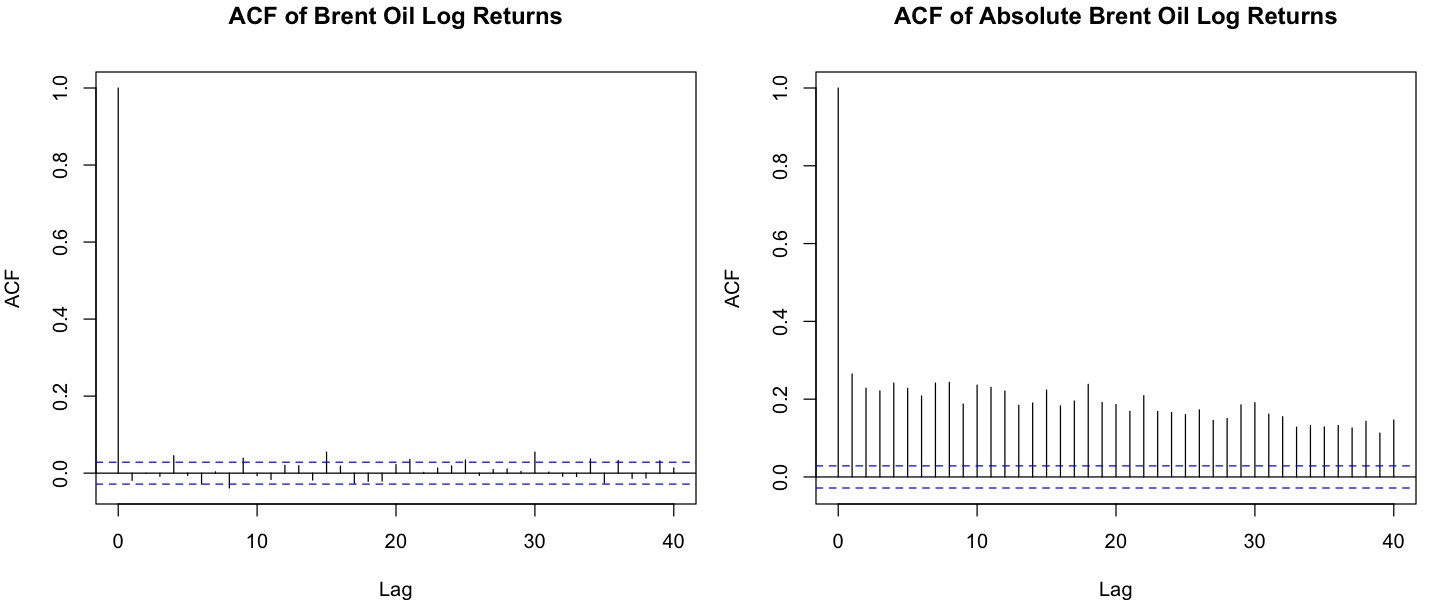

In [22]:
# ACF diagnostics
options(repr.plot.width = 12,repr.plot.height = 5)
par(mfrow = c(1, 2),mar = c(4, 4, 3, 1))

acf(rvec,lag.max = 40,main = "ACF of Brent Oil Log Returns")
acf(abs(rvec),lag.max = 40,main = "ACF of Absolute Brent Oil Log Returns")

par(mfrow = c(1, 1))


- Most autocorrelations are close to zero, although isolated lags may cross the confidence limits. There is no strong persistent evidence that the direction of Brent returns is serially correlated.

- Absolute-return autocorrelations are positive and significant across many lags. This is strong evidence that large Brent price movements tend to cluster through time.

In [23]:
# Specify the model GARCH(1,1)-t 
garch_spec <- ugarchspec(
  variance.model = list(model = "sGARCH", garchOrder = c(1, 1)),
  mean.model = list(armaOrder = c(0, 0), include.mean = TRUE),
  distribution.model = "std"
)

garch_spec 


*---------------------------------*
*       GARCH Model Spec          *
*---------------------------------*

Conditional Variance Dynamics 	
------------------------------------
GARCH Model		: sGARCH(1,1)
Variance Targeting	: FALSE 

Conditional Mean Dynamics
------------------------------------
Mean Model		: ARFIMA(0,0,0)
Include Mean		: TRUE 
GARCH-in-Mean		: FALSE 

Conditional Distribution
------------------------------------
Distribution	:  std 
Includes Skew	:  FALSE 
Includes Shape	:  TRUE 
Includes Lambda	:  FALSE 


In [25]:
# Estimate the GARCH model
garch_fit <- ugarchfit(garch_spec, data = logret, solver = "hybrid")
garch_fit


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: sGARCH(1,1)
Mean Model	: ARFIMA(0,0,0)
Distribution	: std 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000694    0.000236   2.9420 0.003261
omega   0.000005    0.000002   2.4588 0.013941
alpha1  0.086077    0.009676   8.8963 0.000000
beta1   0.909291    0.009840  92.4045 0.000000
shape   5.508669    0.431194  12.7754 0.000000

Robust Standard Errors:
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000694    0.000246   2.8148 0.004881
omega   0.000005    0.000004   1.2536 0.209975
alpha1  0.086077    0.012275   7.0125 0.000000
beta1   0.909291    0.014925  60.9252 0.000000
shape   5.508669    0.458693  12.0095 0.000000

LogLikelihood : 11938.46 

Information Criteria
------------------------------------
                 

In [26]:
cat("Convergence code:", garch_fit@fit$convergence, "\n")

Convergence code: 0 


In [27]:
# Extract GARCH parameters
garch.parameters <- coef(garch_fit)

alpha1 <- as.numeric(garch.parameters["alpha1"])
beta1 <- as.numeric(garch.parameters["beta1"])
shape <- as.numeric(garch.parameters["shape"])
persistence <- alpha1 + beta1

cat("alpha1:",sprintf("%.6f", alpha1),"\n")
cat("beta1:",sprintf("%.6f", beta1),"\n")
cat("shape:",sprintf("%.6f", shape),"\n")
cat("Volatility persistence:",sprintf("%.6f", persistence),"\n")

alpha1: 0.086077 
beta1: 0.909291 
shape: 5.508669 
Volatility persistence: 0.995368 


The persistence estimate is close to one, indicating that volatility shocks decay slowly.

In [32]:
# Bootstrap one-day GARCH outcomes
suppressWarnings(RNGkind(sample.kind = "Rounding"))

set.seed(123789)

garch_boot <- ugarchboot(garch_fit,method = "Partial",sampling = "raw",
  n.ahead = 1,n.bootpred = 100000,solver = "solnp")

garch_simulated_returns <- as.vector(garch_boot@fseries)

cat("Number of simulated returns:",length(garch_simulated_returns), "\n")
summary(garch_simulated_returns)

Number of simulated returns: 100000 


      Min.    1st Qu.     Median       Mean    3rd Qu.       Max. 
-0.1970390 -0.0147268  0.0007411 -0.0003061  0.0155516  0.1783279 

In [34]:
# Calculate 95% GARCH VaR & ES
alpha95 <- 0.05

garch_var <- as.numeric(quantile(garch_simulated_returns,probs = alpha95))
garch_es <- mean(garch_simulated_returns[garch_simulated_returns < garch_var])

cat("GARCH one-day 95% VaR:",sprintf("%.6f", garch_var), "\n")
cat("GARCH one-day 95% ES:",sprintf("%.6f", garch_es), "\n")

GARCH one-day 95% VaR: -0.043879 
GARCH one-day 95% ES: -0.064021 


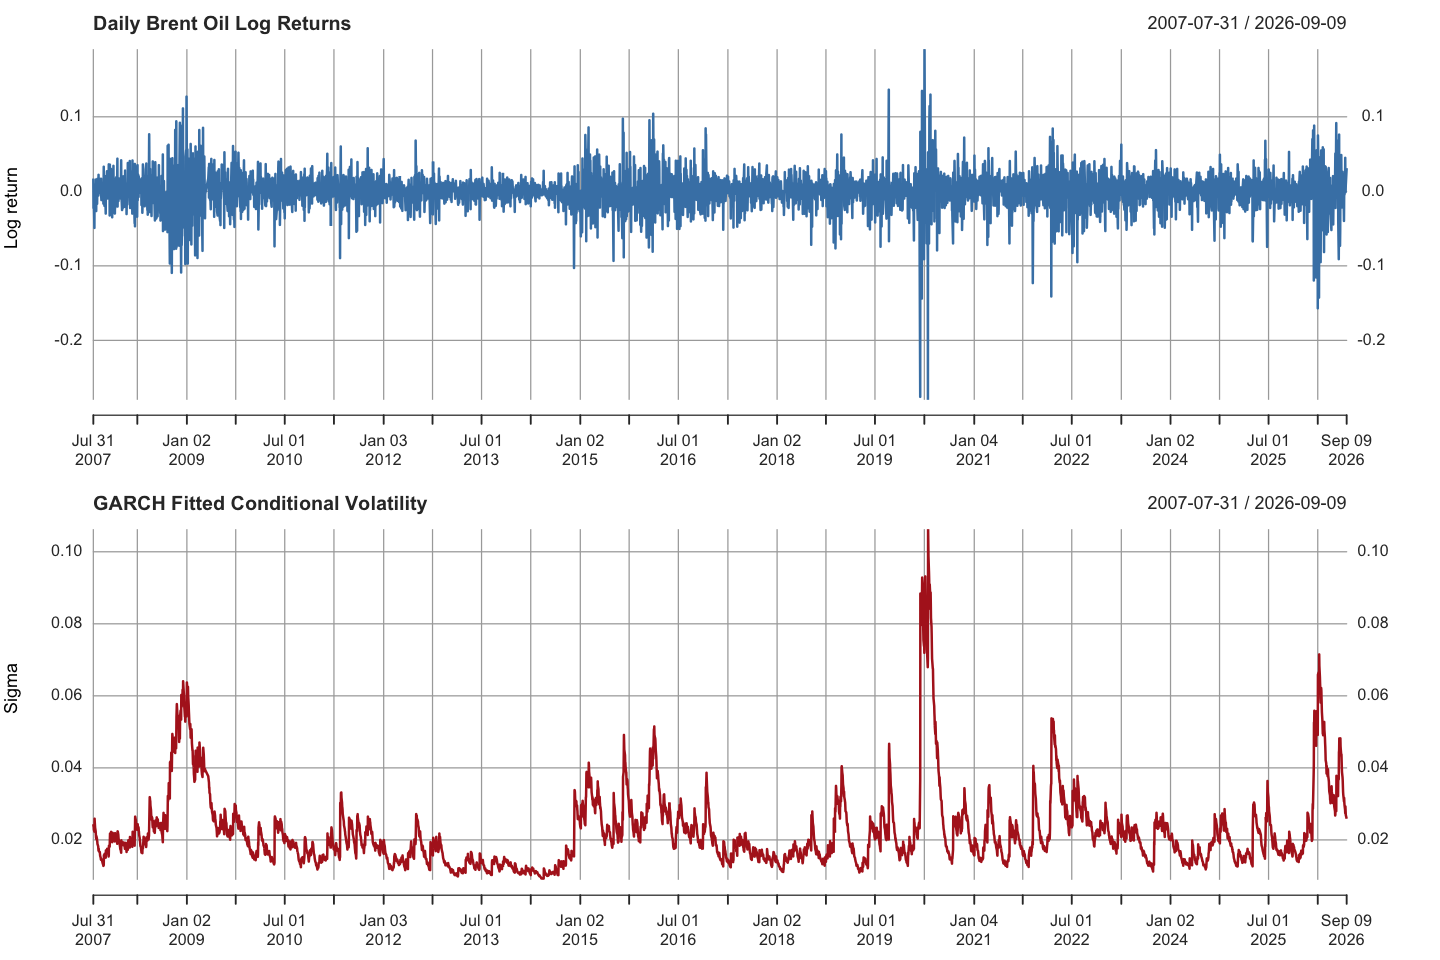

In [36]:
# Plot returns and fitted volatility
options(repr.plot.width = 12,repr.plot.height = 8)
par(mfrow = c(2, 1),mar = c(3, 4, 3, 1))

plot(logret,main = "Daily Brent Oil Log Returns",ylab = "Log return",col = "steelblue")

plot(sigma(garch_fit),main = "GARCH Fitted Conditional Volatility",ylab = "Sigma",col = "firebrick")

par(mfrow = c(1, 1))

Estimated volatility rises sharply during turbulent periods and declines gradually afterward. 

Persistence is close to one, meaning that volatility shocks decay slowly and risk remains elevated after major market moves.

The GARCH volatility graph captures this clustering and shows that large volatility shocks decline gradually rather than disappearing immediately.

**Main conclusions:**
- Brent oil returns are not normally distributed; they have heavy tails and negative skewness.
- Normal VaR and ES underestimate downside risk relative to empirical and heavy-tailed approaches.
- Absolute-return autocorrelation confirms volatility clustering.
- The GARCH(1,1)-t model captures time-varying volatility and produces risk estimates that respond to current market conditions.
- For a multi-day horizon, block simulation is the most conservative method in this sample because it preserves consecutive return patterns.
